# 약물 탐지 2-Stage 파이프라인 튜토리얼

**목적**: YOLO26n 기반 약물 탐지(Stage 1) + 분류(Stage 2) 파이프라인 전체 과정을 학습하고 실행

**대상**: 팀 신입, ML 초보자 ~ 데이터 사이언티스트  
**소요 시간**: 약 30분 (GPU 환경 기준)  
**사전 요구사항**: `pip install -r requirements.txt`, `pip install -e .`, GPU 환경 (권장)

---

## 유틸 함수 지도

튜토리얼에서 자주 쓰는 시각화/리포트 유틸은 `src.utils.visualize`, `src.utils.report`에 모여 있다. 

### `src.utils.visualize`

| 함수 | 용도 | 대표 입력 |
|---|---|---|
| `plot_training_curves` | Stage 1 학습 loss / mAP 곡선 확인 | `results.csv` |
| `plot_s1_gt_vs_pred` | Stage 1 GT bbox와 예측 bbox 비교 | `predictions`, val image/label dir |
| `plot_crop_showcase` | 탐지 수가 많은 이미지 1장의 원본 + crop 나열 | inference manifest, crop dir, image dir |
| `plot_crop_grid` | crop 이미지 랜덤 샘플 그리드 확인 | crop dir |
| `plot_pipeline_overlay` | 원본 이미지 위에 bbox + Stage 2 class overlay | `pipeline_by_img`, image dir |
| `plot_pipeline_strip` | 원본 + crop + 분류 결과를 한 줄 스트립으로 확인 | `pipeline_by_img`, crop dir, image dir |

### `src.utils.report`

| 함수 | 용도 | 대표 입력 |
|---|---|---|
| `load_timings` | `timings.json`을 dict로 로드 | experiment dir |
| `print_timings` | Stage 1 / crop / Stage 2 / pipeline 소요 시간 요약 | experiment dir |
| `load_s1_best_metrics` | `results.csv`에서 best Stage 1 지표 로드 | `results.csv` |
| `load_s2_best_metrics` | Stage 2 checkpoint에서 best 지표 로드 | `best.pt` |

간단 사용 예:

```python
import importlib
import src.utils.visualize as viz
from src.utils import report

importlib.reload(viz)

viz.plot_crop_grid(CROP_DIR, n=16)
viz.plot_pipeline_strip(pipeline_by_img, CROP_DIR, VAL_IMG_DIR, save_dir=Path(f"experiments/{EXP_NAME}"))

report.print_timings(Path(f"experiments/{EXP_NAME}"))
print(report.load_s1_best_metrics(RESULTS_CSV))
print(report.load_s2_best_metrics(BEST_PT_S2))
```


## 📌 파이프라인 개요

### 왜 2-Stage 파이프라인인가?

1장의 약물 이미지에는 **여러 종류의 알약**이 섞여 있을 수 있습니다.
- **Stage 1 (탐지)**: "어디에 알약이 있는가?" → 각 알약의 위치(bbox) 찾기
- **Stage 2 (분류)**: "이것이 무엇인가?" → 찾은 각 알약의 약품명 분류

### 전체 흐름

```
원본 이미지
    ↓
[Stage 1: YOLO26n 탐지]
  · 학습: 약물 위치 annotation으로 학습
  · 추론: 이미지 → bbox 리스트
    ↓
[Stage 2: ResNet50 분류]
  · 학습: bbox를 crop한 이미지 + 약품명 label로 학습
  · 추론: 각 crop → 약품명 예측
    ↓
최종 결과: [약물위치, 약품명, 신뢰도]
```

### 입출력 형식

| 단계 | 입력 | 출력 | 형식 |
|------|------|------|------|
| **Stage 1 학습** | `data/processed/images/train/*.jpg` + YOLO format labels | 모델 가중치 | `.pt` |
| **Stage 1 추론** | `data/processed/images/val/*.jpg` | `predictions.json` | `{"image_id", "detections": [{bbox, score}]}` |
| **Stage 2 학습** | Crop 이미지 + 분류 label | 분류기 가중치 | `.pt` |
| **Stage 2 추론** | Crop 이미지 | `predictions.json` | `{"crop_id", "class_name", "score"}` |

---

## ⚙️ 1. 환경 설정

먼저 작업 디렉토리와 필수 라이브러리를 로드합니다.


In [31]:
import os
from pathlib import Path

# 프로젝트 루트 설정
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "experiments").exists() else _cwd.parent
os.chdir(PROJECT_ROOT)

try:
    import src  # noqa: F401
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "현재 커널에서 src 패키지를 찾을 수 없습니다. "
        "프로젝트 루트(Main)에서 'pip install -e .'를 실행한 뒤 "
        "노트북 커널을 재시작하세요."
    ) from exc

print(f"✓ 작업 디렉토리: {os.getcwd()}")
print("✓ editable install import 확인: from src... 사용 가능")

✓ 작업 디렉토리: /home/n132/Projects/Project1/Main


In [50]:
# 시각화·분석용 라이브러리
try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    import subprocess

    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib"])
    import koreanize_matplotlib  # noqa: F401, E402

import json
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import yaml
import pandas as pd
from PIL import Image

print("✓ 모든 라이브러리 로드 완료")

✓ 모든 라이브러리 로드 완료


## 2️⃣ 경로 및 설정 확인

학습과 추론에 사용할 설정 파일, 데이터 경로, 출력 디렉토리를 정의합니다.


In [33]:
# ============ 경로 변수 (수정하지 말 것) ============
# 실험 이름
EXP_NAME = "exp_20260420_baseline_yolo26n"

# 설정 파일 경로
S1_CONFIG = f"experiments/{EXP_NAME}/s1_config.yaml"  # Stage 1 설정
S2_CONFIG = "experiments/stage2_classifier/config.yaml"  # Stage 2 설정
DATA_YAML = "data/processed/dataset.yaml"  # 데이터셋 정의
VAL_IMG_DIR = Path("data/processed/images/val")  # val 원본 이미지
VAL_LABEL_DIR = Path("data/processed/labels/val")  # val YOLO 라벨

# 모델 가중치 경로
BEST_PT_S1 = f"experiments/{EXP_NAME}/weights/best.pt"  # Stage 1 best 모델
BEST_PT_S2 = "experiments/stage2_classifier/exp_YYYYMMDD_resnet50_baseline/weights/best.pt"  # Stage 2 best 모델

# 입출력 경로
RESULTS_CSV = f"experiments/{EXP_NAME}/results.csv"  # Stage 1 학습 로그
PRED_OUTPUT = f"experiments/{EXP_NAME}/val_predictions.json"  # Stage 1 추론 결과
CROP_DIR = Path(f"experiments/{EXP_NAME}/stage1_crops")  # Stage 1 추론 crop (시각화용)
GT_CROP_DIR = Path("data/processed/crops")  # GT crop (Stage 2 학습용)
S2_PRED_OUTPUT = f"experiments/{EXP_NAME}/stage2_predictions.json"  # Stage 2 추론 결과

# ============ 경로 존재 확인 ============
paths_to_check = {
    "S1 설정": S1_CONFIG,
    "S2 설정": S2_CONFIG,
    "데이터": DATA_YAML,
    "val 이미지": str(VAL_IMG_DIR),
    "val 라벨": str(VAL_LABEL_DIR),
    "GT crop": str(GT_CROP_DIR),
}

print("\n경로 확인:")
print("-" * 50)
for name, path in paths_to_check.items():
    exists = "✓" if Path(path).exists() else "✗"
    print(f"{exists} {name:15s}: {path}")
print("-" * 50)



경로 확인:
--------------------------------------------------
✓ S1 설정          : experiments/exp_20260420_baseline_yolo26n/s1_config.yaml
✓ S2 설정          : experiments/stage2_classifier/config.yaml
✓ 데이터            : data/processed/dataset.yaml
✓ val 이미지        : data/processed/images/val
✓ val 라벨         : data/processed/labels/val
✓ GT crop        : data/processed/crops
--------------------------------------------------


In [34]:
# Run All 시 학습을 건너뛰려면 False 유지, 재학습 시에만 True로 변경
RUN_TRAIN_S1 = False
RUN_TRAIN_S2 = False

print(f'RUN_TRAIN_S1 = {RUN_TRAIN_S1}')
print(f'RUN_TRAIN_S2 = {RUN_TRAIN_S2}')


RUN_TRAIN_S1 = False
RUN_TRAIN_S2 = False


### 설정 파일 확인

**Stage 1 설정** — YOLO26n 모델 학습 파라미터:


In [35]:
with open(S1_CONFIG) as f:
    cfg = yaml.safe_load(f)

# 핵심 설정만 출력
print("\n📋 Stage 1 주요 설정:")
print("-" * 50)
print(f"  모델: {cfg['model']['name']}")
print(f"  이미지 크기: {cfg['data']['imgsz']}x{cfg['data']['imgsz']}")
print(f"  에포크: {cfg['train']['epochs']}")
print(f"  배치 크기: {cfg['train']['batch']}")
print(f"  Seed: {cfg['seed']} (재현성 보장)")
print("-" * 50)


📋 Stage 1 주요 설정:
--------------------------------------------------
  모델: yolo26n
  이미지 크기: 640x640
  에포크: 100
  배치 크기: 16
  Seed: 42 (재현성 보장)
--------------------------------------------------


### 데이터셋 확인

YOLO 형식 데이터셋 구조:
- **Train**: 학습용 이미지 + YOLO format label
- **Val**: 검증용 이미지 (파이프라인 시각화용)
- **Test**: 최종 테스트 (kaggle 제출용)


In [36]:
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

DATA_YAML_DIR = Path(DATA_YAML).parent

print("\n📊 데이터셋 구성:")
print("-" * 50)
for split in ["train", "val", "test"]:
    p = (DATA_YAML_DIR / data_cfg[split]).resolve()
    count = (
        len(list(p.glob("*.jpg"))) + len(list(p.glob("*.png"))) if p.exists() else -1
    )
    status = "✓" if p.exists() else "✗"
    print(f"{status} {split:6s}: {count:4d} images  →  {p}")

VAL_IMG_DIR = (DATA_YAML_DIR / data_cfg["val"]).resolve()
print("-" * 50)


📊 데이터셋 구성:
--------------------------------------------------
✓ train : 3981 images  →  /home/n132/Projects/Project1/Main/data/processed/images/train
✓ val   :  497 images  →  /home/n132/Projects/Project1/Main/data/processed/images/val
✓ test  :  499 images  →  /home/n132/Projects/Project1/Main/data/processed/images/test
--------------------------------------------------


---

## 🎯 Stage 1: 약물 탐지 모델 학습

### Step 1-1: 모델 학습

YOLO26n을 약물 탐지 데이터로 학습합니다.

**입력**: `data/processed/images/train/` (학습 이미지)  
**출력**: `experiments/{EXP_NAME}/weights/best.pt` (최고 성능 모델)

실행 시간: GPU 기준 ~10분

```bash
# 코드 해설:
# - train.py: 학습 스크립트
# - --config: 위에서 확인한 설정 파일
# - --data: 데이터셋 yaml 파일
```


In [37]:
import subprocess, sys

print('\n🚀 Stage 1 학습...')
print('=' * 50)
if RUN_TRAIN_S1:
    subprocess.run(
        [sys.executable, 'scripts/train.py',
         '--config', S1_CONFIG,
         '--data',   DATA_YAML],
        check=True
    )
    print('✓ Stage 1 학습 완료')
else:
    print('⏭  학습 스킵 (RUN_TRAIN_S1=False)')



🚀 Stage 1 학습...
⏭  학습 스킵 (RUN_TRAIN_S1=False)


### Step 1-2: 모델 검증

학습된 모델을 검증 데이터에서 평가합니다.

**메트릭**:
- **Precision (P)**: 탐지한 것 중 정답 비율
- **Recall (R)**: 정답 중 탐지한 비율
- **mAP50**: IoU 0.5 기준 평균 정밀도 (일반적)
- **mAP50-95**: IoU 0.5~0.95 기준 평균 정밀도 (엄격함)

목표: mAP50 > 0.95, mAP50-95 > 0.90


In [38]:
# Stage 1 검증 실행
print("\n🔍 Stage 1 검증 실행...")
print("=" * 50)
!python scripts/validate.py \
    --config  {S1_CONFIG} \
    --data    {DATA_YAML}
print("=" * 50)
print("✓ Stage 1 검증 완료\n")


🔍 Stage 1 검증 실행...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 140.6±25.4 MB/s, size: 51.4 KB)
val: Scanning /home/n132/Projects/Project1/Main/data/processed/labels/val.cache... 497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 497/497 104.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 6.6it/s 4.9s0.1s
                   all        497        547      0.996      0.998      0.994      0.934
Speed: 1.6ms preprocess, 3.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/n132/Projects/Project1/Main/runs/detect/val-51
⏱  s1_validate: 6.9초
mAP50=0.9938  mAP50-95=0.9339
✓ Stage 1 검증 완료



### Step 1-3: 학습 곡선 시각화

Loss와 mAP 추이를 확인하여 모델 수렴성을 판단합니다.


✓ 저장: experiments/exp_20260420_baseline_yolo26n/training_curves.png


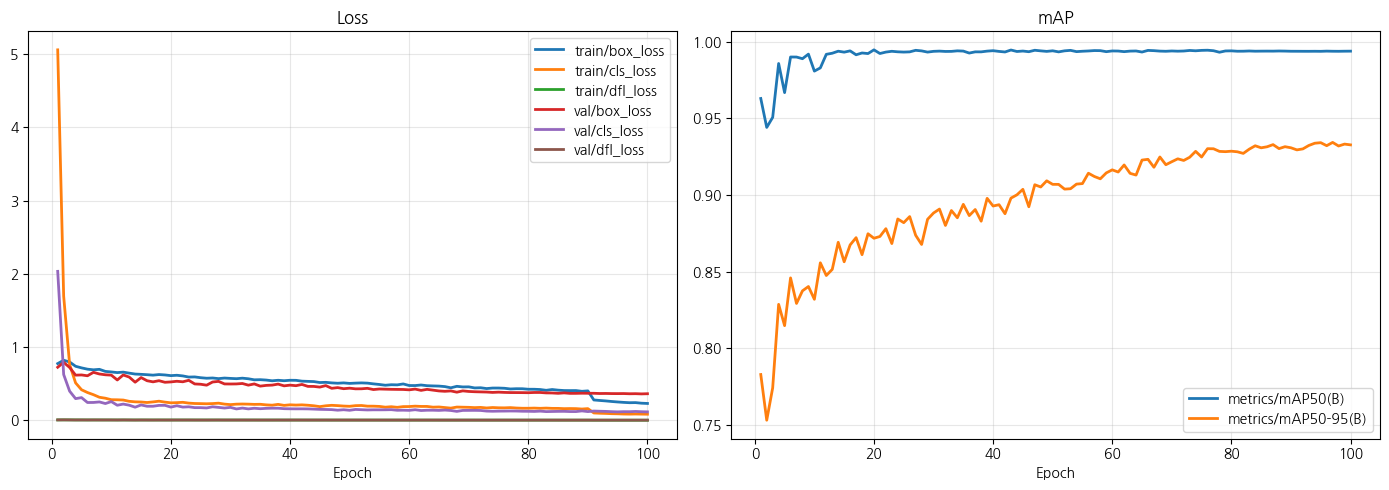

In [39]:
from src.utils.visualize import plot_training_curves

# 경로 변수 셀을 건너뛰고 실행한 경우를 위한 fallback
if "RESULTS_CSV" not in globals():
    RESULTS_CSV = f"experiments/{EXP_NAME}/results.csv"

if Path(RESULTS_CSV).exists():
    plot_training_curves(RESULTS_CSV, save_dir=Path(f"experiments/{EXP_NAME}"))
else:
    print(f"⚠️ results.csv 없음: {RESULTS_CSV}")
    print("   Stage 1 학습 셀을 실행했거나, 실험 경로가 맞는지 확인하세요.")


### Step 1-4: 추론 실행

학습된 모델로 검증 데이터에 대해 추론을 수행합니다.

**출력**: `val_predictions.json`
```json
{
  "image_id": "...",
  "detections": [
    {"bbox": [x1, y1, x2, y2], "score": 0.95},
    ...
  ]
}
```

이 결과를 Stage 2 입력으로 사용합니다.


In [40]:
print("\n🔮 Stage 1 추론 실행...")
print("=" * 50)
!python scripts/predict.py \
    --config  {S1_CONFIG} \
    --source  {VAL_IMG_DIR} \
    --output  {PRED_OUTPUT}
print("=" * 50)

# 결과 통계
with open(PRED_OUTPUT) as f:
    predictions = json.load(f)

total_det = sum(len(p["detections"]) for p in predictions)
avg_det = total_det / max(len(predictions), 1)

print("\n📊 추론 결과 통계:")
print(f"  이미지 수: {len(predictions)}장")
print(f"  총 탐지: {total_det}개")
print(f"  평균 탐지: {avg_det:.2f}개/장")
print()


🔮 Stage 1 추론 실행...

image 1/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_125mg-Madopar-HBS-cap-_jpg.rf.1816183d8912e67d3a8e14f9204e5e02.jpg: 640x640 1 pill, 12.6ms
image 2/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_125mg-Madopar-HBS-cap_12_jpg.rf.6056b05c6f5934678b2415423b11dc14.jpg: 640x640 1 pill, 15.3ms
image 3/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_074544051_iOS_jpg.rf.45b1ee23f3d21d0fb618c81544727e2f.jpg: 640x640 1 pill, 23.6ms
image 4/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_075432749_iOS_jpg.rf.7935e9ef2b6e81da4ee5e506d8e17302.jpg: 640x640 1 pill, 35.2ms
image 5/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_080700940_iOS_jpg.rf.f4c87c380180c441af59107b651fe8fa.jpg: 640x640 1 pill, 19.9ms
image 6/497 /home/n132/Projects/Project1/Main/data/processed/images/val/ext_20230316_081348776_iOS_jpg.rf.3dfed0d7aac31c2a32f2bb6b764f3718.jpg

### Step 1-5: 결과 시각화 — 멀티 탐지 케이스

GT(초록) vs 예측(빨강) 박스를 비교합니다. 알약 2개 이상인 이미지에서 모델 성능을 확인합니다.


멀티 알약 이미지: 23개 / 전체 497개


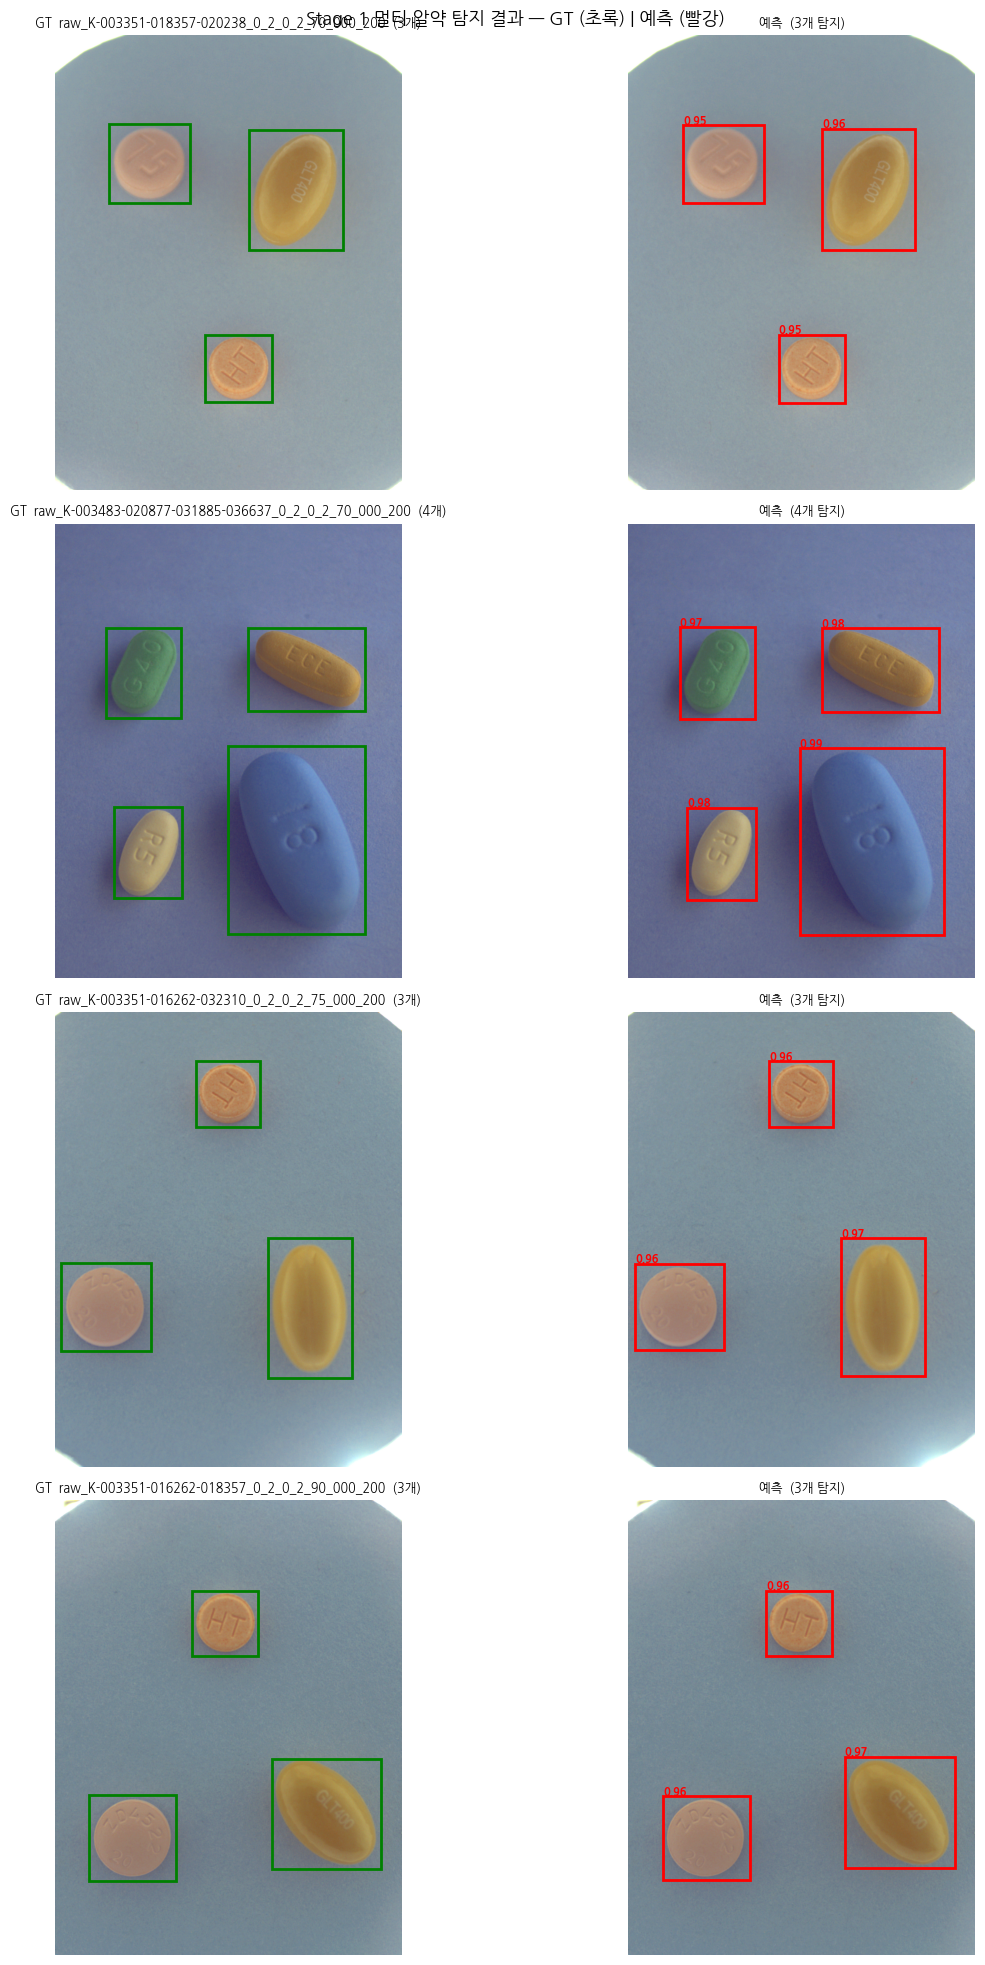

In [41]:
from src.utils.visualize import plot_s1_gt_vs_pred

# 경로 변수 셀을 건너뛰고 실행한 경우를 위한 fallback
if "VAL_IMG_DIR" not in globals():
    VAL_IMG_DIR = Path("data/processed/images/val")
if "VAL_LABEL_DIR" not in globals():
    VAL_LABEL_DIR = Path("data/processed/labels/val")

if "predictions" not in globals():
    print("⚠️ predictions 없음 — Stage 1 추론 결과 로드/생성 셀을 먼저 실행하세요.")
elif not Path(VAL_IMG_DIR).exists():
    print(f"⚠️ val 이미지 디렉터리 없음: {VAL_IMG_DIR}")
elif not Path(VAL_LABEL_DIR).exists():
    print(f"⚠️ val 라벨 디렉터리 없음: {VAL_LABEL_DIR}")
else:
    plot_s1_gt_vs_pred(predictions, VAL_IMG_DIR, VAL_LABEL_DIR)


### Step 1-6: Crop 추출

Stage 1 추론 결과의 bbox를 기준으로 이미지를 잘라냅니다. 이 crop은 Stage 2 입력으로 사용됩니다.

**입력**: `val_predictions.json`, 원본 이미지  
**출력**: `stage1_crops/` (개별 crop 이미지들), `crops_manifest.json` (메타데이터)


In [42]:
print("\n✂️  Crop 추출 중...")
print("=" * 50)
!python scripts/pipeline/crop.py \
    --predictions {PRED_OUTPUT} \
    --source      {VAL_IMG_DIR} \
    --output      {CROP_DIR} \
    --padding     0.05
print("=" * 50)

# Crop 통계
with open(CROP_DIR / "crops_manifest.json") as f:
    manifest = json.load(f)

print(f"\n✓ Crop 추출 완료: {len(manifest)}개 이미지")


✂️  Crop 추출 중...
⏱  crop: 1.3초
크롭 완료: 554개 → experiments/exp_20260420_baseline_yolo26n/stage1_crops

✓ Crop 추출 완료: 554개 이미지


### Manifest 역할 정리

이 튜토리얼에서는 crop manifest를 용도별로 분리해서 사용한다.

| manifest 종류 | 생성 모드 | 주요 필드 | 용도 |
|---|---|---|---|
| GT crop manifest | `crop.py --labels ... --images ...` 또는 이미 준비된 crop manifest | `crop_path`, `class_name`, 선택적으로 `image_id`, `bbox` | Stage 2 학습/분류 평가 |
| ImageFolder manifest | `crop.py --imagefolder ...` | `crop_path`, `class_name` | 이미 잘린 crop을 Stage 2 학습 인터페이스에 연결 |
| Inference crop manifest | `crop.py --predictions ... --source ...` | `crop_id`, `image_id`, `bbox`, `score` | 복원 시각화, e2e 평가, Kaggle 제출 |

Kaggle 제출에는 반드시 `data/test`에서 Stage 1 예측으로 만든 inference crop manifest를 사용한다. GT crop manifest나 ImageFolder manifest는 제출 입력으로 쓰지 않는다.


### Step 1-7: Crop 품질 확인

탐지한 알약들이 제대로 crop되었는지 시각적으로 확인합니다.


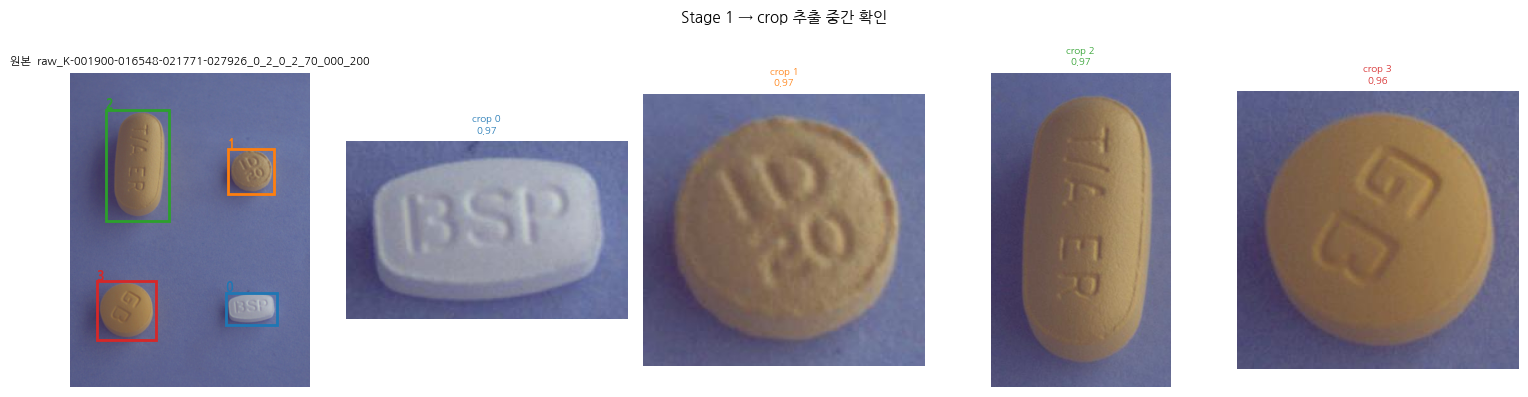

In [43]:
from src.utils.visualize import plot_crop_showcase

plot_crop_showcase(manifest, CROP_DIR, VAL_IMG_DIR)


---

## 🎯 Stage 2: 약물 분류 모델

### Step 2-0: GT Crop 생성 (최초 1회)

Stage 2 학습을 위해 GT label 기반 crop을 생성합니다. 이미 존재하면 건너뜁니다.

**출력**: `data/processed/crops/{train,val}/`


In [44]:
print("\n📦 GT Crop 생성 (또는 로드)...")
print("=" * 50)

if not (GT_CROP_DIR / "train" / "crops_manifest.json").exists():
    print("⏳ 첫 실행 — GT crop 생성 중... (1-2분)")
    !python scripts/pipeline/crop.py \
        --imagefolder data/processed/crops \
        --splits      train val
else:
    import json
    with open(GT_CROP_DIR / "train" / "crops_manifest.json") as f:
        gt_manifest = json.load(f)
    print("✓ GT crop 이미 존재")
    print(f"  Train: {len(gt_manifest)}개 crop")
    
    with open(GT_CROP_DIR / "val" / "crops_manifest.json") as f:
        gt_manifest_val = json.load(f)
    print(f"  Val: {len(gt_manifest_val)}개 crop")

print("=" * 50)


📦 GT Crop 생성 (또는 로드)...
✓ GT crop 이미 존재
  Train: 4205개 crop
  Val: 795개 crop


### Step 2-1: 분류 모델 학습

GT crop 이미지들로 약품명 분류 모델(ResNet50)을 학습합니다.

**입력**: `data/processed/crops/{train,val}/` (crop 이미지 + 폴더명 = class)  
**출력**: `experiments/stage2_classifier/weights/best.pt`

학습 시간: GPU 기준 ~10분


In [45]:
print('\n🚀 Stage 2 분류기 학습...')
print('=' * 50)
if RUN_TRAIN_S2:
    subprocess.run(
        [sys.executable, 'scripts/pipeline/stage2_train.py',
         '--config', S2_CONFIG],
        check=True
    )
    print('✓ Stage 2 학습 완료')
else:
    print('⏭  학습 스킵 (RUN_TRAIN_S2=False)')



🚀 Stage 2 분류기 학습...
⏭  학습 스킵 (RUN_TRAIN_S2=False)


In [46]:
# Stage 2 체크포인트 지표 확인
import torch

if not Path(BEST_PT_S2).exists():
    print('⚠️  가중치 없음 — Step 2-1 학습을 먼저 실행하세요')
else:
    _ck = torch.load(BEST_PT_S2, map_location='cpu')
    _metrics = _ck.get('metrics', {})
    _nc = len(_ck.get('class_names', []))
    print(f'Stage 2  best epoch : {_ck["epoch"] + 1}')
    print(f'  Top-1 Acc         : {_metrics.get("top1_acc", _ck.get("top1_acc", "N/A"))}')
    print(f'  Top-5 Acc         : {_metrics.get("top5_acc", _ck.get("top5_acc", "N/A"))}')
    print(f'  학습 클래스 수    : {_nc}')


Stage 2  best epoch : 26
  Top-1 Acc         : 0.06918238993710692
  Top-5 Acc         : N/A
  학습 클래스 수    : 279


### Step 2-2: 분류 추론

Stage 1에서 추출한 crop 이미지들을 분류합니다.

**입력**: `stage1_crops/*.jpg`  
**출력**: `stage2_predictions.json`
```json
{
  "crop_id": "...",
  "class_name": "아스피린",
  "score": 0.92
}
```


In [47]:
print("\n🔮 Stage 2 추론 실행...")
print("=" * 50)

if not Path(BEST_PT_S2).exists():
    print("⚠️  Stage 2 모델 가중치 없음 — Step 2-1을 먼저 실행하세요")
else:
    !python scripts/pipeline/stage2_predict.py \
        --config  {S2_CONFIG} \
        --weights {BEST_PT_S2} \
        --source  {CROP_DIR} \
        --output  {S2_PRED_OUTPUT}

print("=" * 50)
print()


🔮 Stage 2 추론 실행...
⏱  s2_predict: 2.4초
추론 완료: 561개 → experiments/exp_20260420_baseline_yolo26n/stage2_predictions.json



### Step 2-3: End-to-end mAP 평가

`evaluate_pipeline.py`는 GT label + Stage 1 crops manifest + Stage 2 predictions를 받아
파이프라인 전체의 **e2e mAP**를 계산한다.

| 지표 | 설명 |
|------|------|
| `mAP@[0.50:0.95]` | COCO 표준 지표 |
| `mAP@[0.75:0.95]` | **Kaggle 제출 평가 지표** (엄격한 IoU 기준) |
| `mAP@0.50` | 전통적 Pascal VOC 지표 |

> score = `det_score` (crops_manifest) × `cls_score` (stage2_predictions)

```bash
python scripts/pipeline/evaluate_pipeline.py \
    --gt-labels data/processed/labels/val \
    --gt-images data/processed/images/val \
    --s1-crops  experiments/{EXP}/stage1_crops/crops_manifest.json \
    --s2-preds  experiments/{EXP}/stage2_predictions.json

# 클래스별 AP 상위 20개 추가 출력
python scripts/pipeline/evaluate_pipeline.py ... --per-class
```


In [48]:
print('\n📐 End-to-end mAP 평가...')
print('=' * 50)

MANIFEST_PATH = str(CROP_DIR / 'crops_manifest.json')
VAL_LABEL_DIR = 'data/processed/labels/val'
VAL_IMG_DIR   = 'data/processed/images/val'

if not Path(MANIFEST_PATH).exists():
    print('⚠️  crops_manifest.json 없음 — Step 1-6 crop 추출을 먼저 실행하세요')
elif not Path(S2_PRED_OUTPUT).exists():
    print('⚠️  stage2_predictions.json 없음 — Step 2-2 추론을 먼저 실행하세요')
else:
    import subprocess, sys
    result = subprocess.run(
        [sys.executable, 'scripts/pipeline/evaluate_pipeline.py',
         '--gt-labels', VAL_LABEL_DIR,
         '--gt-images', VAL_IMG_DIR,
         '--s1-crops',  MANIFEST_PATH,
         '--s2-preds',  S2_PRED_OUTPUT],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.stderr:
        print('[stderr]', result.stderr[:300])



📐 End-to-end mAP 평가...
GT     : 456장  503개 객체
Pred   : 554개 / 198클래스 평가  [Stage 2 학습 클래스 기준]
mAP@[0.50:0.95] : 0.8567  (COCO)
mAP@[0.75:0.95] : 0.8037  (Kaggle)
mAP@0.50        : 0.9097
mAP@0.75        : 0.9097



### Step 2-4: Kaggle test 제출 파일 생성

`make_submission.py`는 inference `crops_manifest.json`과 Stage 2 predictions를 `crop_id`로 병합해 `submission.csv`를 만든다.

제출은 Kaggle test 전용 흐름이다.

```text
data/test 원본 이미지
-> Stage 1 predict
-> inference crop + crops_manifest.json
-> Stage 2 predict
-> make_submission.py
```

중요 규칙:

- `--manifest`에는 test inference crop manifest를 넣는다.
- `1.png -> 1_0.jpg, 1_1.jpg`처럼 crop이 나뉘어도 최종 `submission.csv.image_id`는 원본 ID인 `1`이어야 한다.
- `class_map` 밖 예측 클래스는 기본 제외한다.
- 필요한 경우 `--unknown-class-map`으로 map 밖 예측을 Kaggle class name/category_id로 명시 치환한다.
- map 밖 예측을 즉시 에러로 잡고 싶으면 `--strict-class-map`을 사용한다.


In [51]:
print('\n📦 Kaggle test 제출 파일 생성...')
print('=' * 50)

TEST_IMG_DIR = Path('data/test')
TEST_S1_PREDS = Path('data/test/s1_predictions.json')
TEST_CROP_DIR = Path('data/test/s1_crops')
TEST_MANIFEST = TEST_CROP_DIR / 'crops_manifest.json'
TEST_S2_PREDS = Path('data/test/stage2_predictions.json')
SUBMISSION_OUTPUT = Path(f'submissions/{EXP_NAME}_submission.csv')
CLASS_MAP = Path('data/processed/kaggle_class_map.json')
UNKNOWN_CLASS_MAP = Path('data/processed/unknown_class_map.json')

required = {
    'data/test': TEST_IMG_DIR,
    'Stage 1 weights': Path(BEST_PT_S1),
    'Stage 2 weights': Path(BEST_PT_S2),
    'class map': CLASS_MAP,
}
missing = [name for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f'필수 파일/디렉터리가 없습니다: {missing}')

SUBMISSION_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
TEST_CROP_DIR.mkdir(parents=True, exist_ok=True)


def run(cmd):
    print('\n$', ' '.join(map(str, cmd)))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print('[stderr]', result.stderr[:500])
    result.check_returncode()

# 1) Stage 1: test 원본 이미지 -> bbox predictions
run([
    sys.executable, 'scripts/predict.py',
    '--config', S1_CONFIG,
    '--weights', BEST_PT_S1,
    '--source', str(TEST_IMG_DIR),
    '--output', str(TEST_S1_PREDS),
])

# 2) Stage 1 bbox -> inference crop + manifest
run([
    sys.executable, 'scripts/pipeline/crop.py',
    '--predictions', str(TEST_S1_PREDS),
    '--source', str(TEST_IMG_DIR),
    '--output', str(TEST_CROP_DIR),
])

# 3) Stage 2: inference crop -> class predictions
run([
    sys.executable, 'scripts/pipeline/stage2_predict.py',
    '--config', S2_CONFIG,
    '--weights', BEST_PT_S2,
    '--source', str(TEST_CROP_DIR),
    '--output', str(TEST_S2_PREDS),
])

# 4) Submission: crop_id로 manifest와 Stage 2 prediction을 병합
cmd = [
    sys.executable, 'scripts/make_submission.py',
    '--manifest', str(TEST_MANIFEST),
    '--s2-preds', str(TEST_S2_PREDS),
    '--class-map', str(CLASS_MAP),
    '--output', str(SUBMISSION_OUTPUT),
]
if UNKNOWN_CLASS_MAP.exists():
    cmd += ['--unknown-class-map', str(UNKNOWN_CLASS_MAP)]
run(cmd)

manifest = json.loads(TEST_MANIFEST.read_text(encoding='utf-8'))
manifest_image_ids = {str(item['image_id']) for item in manifest}
manifest_crop_ids = {str(item['crop_id']) for item in manifest}
df_sub = pd.read_csv(SUBMISSION_OUTPUT)
submission_image_ids = set(df_sub['image_id'].astype(str))

unknown_image_ids = submission_image_ids - manifest_image_ids
leaked_crop_ids = submission_image_ids & (manifest_crop_ids - manifest_image_ids)
assert not unknown_image_ids, f'manifest 원본 image_id에 없는 제출 image_id: {sorted(unknown_image_ids)[:10]}'
assert not leaked_crop_ids, f'crop_id가 submission image_id로 유출됨: {sorted(leaked_crop_ids)[:10]}'

print(f'\n제출 파일: {SUBMISSION_OUTPUT}')
print(f'행 수: {len(df_sub):,}')
print(f'image_id 수: {len(submission_image_ids):,}')
display(df_sub.head())



📦 Kaggle test 제출 파일 생성...

$ /home/n132/anaconda3/envs/P1/bin/python scripts/predict.py --config experiments/exp_20260420_baseline_yolo26n/s1_config.yaml --weights experiments/exp_20260420_baseline_yolo26n/weights/best.pt --source data/test --output data/test/s1_predictions.json

image 1/842 /home/n132/Projects/Project1/Main/data/test/1.png: 640x512 4 pills, 123.1ms
image 2/842 /home/n132/Projects/Project1/Main/data/test/10.png: 640x512 4 pills, 42.6ms
image 3/842 /home/n132/Projects/Project1/Main/data/test/100.png: 640x512 4 pills, 37.0ms
image 4/842 /home/n132/Projects/Project1/Main/data/test/1003.png: 640x512 4 pills, 12.3ms
image 5/842 /home/n132/Projects/Project1/Main/data/test/1004.png: 640x512 4 pills, 12.4ms
image 6/842 /home/n132/Projects/Project1/Main/data/test/1005.png: 640x512 4 pills, 12.7ms
image 7/842 /home/n132/Projects/Project1/Main/data/test/1006.png: 640x512 4 pills, 12.2ms
image 8/842 /home/n132/Projects/Project1/Main/data/test/1007.png: 640x512 4 pills, 13.3ms
ima

,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,35206,558,73,396,403,0.209041
1,2,1,20877,602,677,253,478,0.119243
2,3,1,4543,174,742,178,290,0.088123
3,4,1,1900,157,252,203,122,0.929467
4,5,10,16548,103,809,240,238,0.675500


### Step 2-5: 소요 시간 확인

각 스크립트는 실행 시 자동으로 `timings.json`에 소요 시간을 기록합니다.
별도 설정 없이도 실험 폴더에 누적됩니다.

| 키 | 기록 시점 | 스크립트 |
|---|---|---|
| `s1_train` | Stage 1 학습 완료 시 | `scripts/train.py` |
| `s1_validate` | Stage 1 검증 완료 시 | `scripts/validate.py` |
| `s1_predict` | Stage 1 추론 완료 시 | `scripts/predict.py` |
| `crop` | Crop 생성 완료 시 | `scripts/pipeline/crop.py` |
| `s2_train` | Stage 2 학습 완료 시 | `scripts/pipeline/stage2_train.py` |
| `s2_predict` | Stage 2 추론 완료 시 | `scripts/pipeline/stage2_predict.py` |
| `pipeline_predict` | 전체 파이프라인 추론 완료 시 | `scripts/pipeline/run_predict.py` |

> **팁**: `pipeline_predict` − (`s1_predict` + `crop` + `s2_predict`) ≈ merge/save 오버헤드

In [52]:
from src.utils.report import print_timings

print_timings(Path(f"experiments/{EXP_NAME}"))



⏱  소요 시간 요약
  S1 학습         :  6184.7초  (103.1분)
  S1 검증         :     6.9초  (0.1분)
  S1 추론         :    34.3초  (0.6분)
  Crop 생성       :     1.3초  (0.0분)
  S2 학습         :  2910.5초  (48.5분)
  S2 추론         :     7.3초  (0.1분)


---

## 📊 2-Stage 통합 결과 시각화

### 최종 결과: 약물 위치 + 약품명 + 신뢰도


In [ ]:
# Stage 1 inference manifest + Stage 2 predictions를 다시 로드해 통합 결과 구성
MANIFEST_PATH = str(CROP_DIR / "crops_manifest.json")

if not Path(MANIFEST_PATH).exists():
    print(f"⚠️ manifest 없음: {MANIFEST_PATH}")
elif not Path(S2_PRED_OUTPUT).exists():
    print("⚠️ Stage 2 추론 결과 없음 — Step 2-2를 먼저 실행하세요")
else:
    with open(MANIFEST_PATH, encoding="utf-8") as f:
        manifest = json.load(f)
    with open(S2_PRED_OUTPUT, encoding="utf-8") as f:
        s2_results = json.load(f)

    s2_by_crop = {r["crop_id"]: r for r in s2_results}
    pipeline_by_img = {}
    missing_s2 = 0
    for item in manifest:
        s2 = s2_by_crop.get(item["crop_id"])
        if s2 is None:
            missing_s2 += 1
            s2 = {}
        pipeline_by_img.setdefault(item["image_id"], []).append(
            {
                "bbox": item["bbox"],
                "det_score": item.get("score", 0.0),
                "crop_id": item["crop_id"],
                "class_name": s2.get("class_name", "?"),
                "class_score": s2.get("score", 0.0),
            }
        )

    multi_count = sum(1 for v in pipeline_by_img.values() if len(v) >= 2)
    print(f"✓ 통합 결과 준비 완료: {len(pipeline_by_img)}장 / crop {len(manifest)}개")
    print(f"  multi 탐지 이미지: {multi_count}장")
    print(f"  Stage 2 매칭 누락 crop: {missing_s2}개")
    print(f"  image_id 예시: {list(pipeline_by_img)[:3]}")


### 결과 1: 오버레이 시각화 — 멀티 탐지 케이스

약물 위치에 약품명을 직접 표시합니다.


In [ ]:
import importlib
import src.utils.visualize as viz
importlib.reload(viz)

if "pipeline_by_img" not in globals():
    print("⚠️ pipeline_by_img 없음 — 바로 위 통합 결과 구성 셀을 먼저 실행하세요")
elif not Path(S2_PRED_OUTPUT).exists():
    print("⚠️ Stage 2 결과 없음")
else:
    # reload된 최신 함수 사용: 이미지가 없는 sample은 건너뛰고 원인을 출력한다.
    viz.plot_pipeline_overlay(
        pipeline_by_img,
        VAL_IMG_DIR,
        save_dir=Path(f"experiments/{EXP_NAME}"),
    )


---

## 💡 결과 해석 및 다음 단계

### 성능 지표 해석

| 메트릭 | 의미 | 목표값 |
|--------|------|--------|
| **S1 Precision** | 탐지한 것 중 정답 비율 | > 0.95 |
| **S1 Recall** | 정답 중 탐지한 비율 | > 0.95 |
| **S1 mAP50** | 탐지 정확도 (관대함) | > 0.95 |
| **S2 Top-1 Accuracy** | 분류 정확도 (1순위만 맞음) | > 0.80 |
| **S2 Top-5 Accuracy** | 분류 정확도 (상위 5개 포함) | > 0.95 |
| **S1 추론 시간** | Stage 1 추론 소요 시간 | < 60초 |
| **Crop 생성 시간** | Crop 추출 소요 시간 | < 10초 |
| **S2 추론 시간** | Stage 2 추론 소요 시간 | < 30초 |
| **파이프라인 총 시간** | 전체 추론 파이프라인 | < 120초 |

### 개선 아이디어

1. **데이터 증강 강화**: albumentations 설정에서 `mosaic`, `mixup` 비율 증가
2. **모델 업그레이드**: `yolo26n` → `yolo26m` (더 큰 모델)
3. **앙상블**: 여러 모델 결과를 앙상블해서 신뢰도 향상
4. **임계값 조정**: 신뢰도 threshold를 조정해 precision/recall 트레이드오프 최적화
5. **하드 샘플 마이닝**: 자주 틀리는 이미지들을 수집해 재학습

### 다음 단계

- ✅ 파이프라인 이해 완료
- 📊 다른 config로 실험 ([참고 가이드](../experiments/README.md))
- 🔧 Kaggle 제출 준비 ([제출 가이드](../scripts/README.md#kaggle-submission))
- 📈 결과 분석 및 보고서 작성

---

### 📚 참고 자료

- **스크립트**: `scripts/` 디렉토리
- **설정**: `experiments/*/config.yaml`
- **데이터**: `data/processed/dataset.yaml`